# Task 1: Article-Type Classification


## Experimental scope and outputs

This is an isolated copy of the corresponding production notebook. Existing model families and tuning experiments are retained. Three additional CNN configurations test filter capacity against `cnn_four_blocks_scheduled`:

| Candidate | Filters by block | Hypothesis |
|---|---|---|
| Reference | 32, 64, 128, 256 | Reproduce the existing four-block architecture |
| `cnn_narrow_scheduled` | 16, 32, 64, 128 | Lower capacity may reduce overfitting |
| `cnn_capped_scheduled` | 32, 64, 128, 128 | Test whether the final block is unnecessarily wide |
| `cnn_wide_scheduled` | 32, 64, 128, 384 | Test whether additional final-block capacity helps |

All four use 96 × 128 RGB input, 3 × 3 kernels, Dense(256), dropout 0.2, initial Adam learning rate 0.001, batch 64, seed 2753, unweighted initial training, identical selection groups and the same plateau scheduler/early stopping. Each receives up to 30 epochs rather than aggressive early elimination. The existing continuation experiments apply only to the original reference; the filter-only comparison below excludes them so training history is not confused with architecture.

There are 12 training runs per target: four MLP configurations, six initial CNN configurations and two reference-CNN continuations. Task 3 has two targets. All three notebooks therefore run 48 fits, with early stopping where applicable. This is a full experimental rerun, not just inference or three extra fits. No repeated-seed experiment is included.

Every candidate is saved immediately after fitting to `models-test/<target>_<method>.keras` with restored best weights, label order and preprocessing metadata. Candidate files are uncalibrated; the final selected `<target>_model.keras` also receives calibration/review metadata. Results and configuration records go to `results-test/`, plots to `figures-test/`. Production notebooks, results, figures and models are not overwritten. The existing frozen data manifests and normalization are read unchanged.

Saved outputs and old numerical conclusions have been cleared. Use the new measured tables to write analysis after execution. Selection uses validation macro-F1, then accuracy, then parameter count. Internal-test evaluation remains descriptive and must not guide configuration selection. Nothing is automatically promoted into production.


## 1. Introduction

This notebook addresses **Task 1: Article-Type Classification** for Assignment 2 by predicting the article type of a fashion product from its RGB image, such as a shirt, dress, or pair of shoes. The task is formulated as **a multi-class image classification problem: each image receives one catalogue article-type label**.

Three neural-network approaches are developed and trained from scratch using TensorFlow/Keras:

- **Shallow MLP (Baseline):** A fully connected network with one 256-unit hidden layer operating on flattened image pixels.
- **Deeper MLP:** A fully connected network with hidden layers of 256, 128, and 64 units, using dropout to reduce overfitting.
- **Convolutional Neural Network (CNN):** A spatial model that learns local image patterns through convolutional layers. The CNN family includes three declared architecture/scheduling configurations.

Performance is assessed using:

- **Accuracy:** The proportion of correctly classified images.
- **Macro-F1:** The primary selection metric, giving equal weight to the F1 scores of classes present in the evaluation partition.
- **Per-class classification reports and confusion matrices:** Evidence of which labels are recognized reliably and which are confused.
- **Learning curves:** Training and validation loss, accuracy, and macro-F1 used to examine convergence and overfitting.
- **Calibration metrics:** Confidence reliability of the selected model, assessed after selection using separate validation groups.

Article categories can share silhouettes and textures, while rare categories have fewer training examples. The analysis therefore considers class support and common confusions alongside overall accuracy.

The workflow covers metadata inspection, preprocessing, model development, comparative evaluation, selection, and export for prediction. All candidates use the same frozen group-isolated data partitions. The internal test has prior development exposure, which remains a limitation after retraining. Numerical findings and the final model judgment must be completed from the new executed results; no winner is assumed in advance.


## 2. Library Imports & Setup

Use the Fashion Keras kernel. The seed controls initialization and augmentation. Float32 is used throughout; GPU availability is reported before models are created.


In [1]:
from pathlib import Path
import sys, json, os, hashlib
from concurrent.futures import ThreadPoolExecutor
ROOT = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / 'scripts' / 'preprocessing.py').is_file()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the fashion-intelligence-classification repository.')
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report, log_loss, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit
from scipy.optimize import minimize_scalar
import tensorflow as tf
from tensorflow import keras
from scripts.preprocessing import task_frame, IMAGE_SIZE, NORMALISATION_PATH, SEED, select_tensorflow_device
DEVICE = select_tensorflow_device()
if not tf.config.list_physical_devices('GPU') and os.environ.get('FASHION_TEST_ALLOW_CPU') != '1':
    raise RuntimeError('No TensorFlow GPU found. Use the WSL Fashion Keras environment; allow CPU explicitly with FASHION_TEST_ALLOW_CPU=1.')
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
OUTPUT, RESULTS, FIGURES = (ROOT / 'models-test', ROOT / 'results-test', ROOT / 'figures-test')
for directory in (OUTPUT, RESULTS, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)
MAX_EPOCHS, BATCH_SIZE = (30, 64)

def stem_for(target):
    return 'article_type' if target == 'articleType' else target
# False for a fresh Run All. Enable only when deliberately resuming matching saved experiments.
RESUME_SAVED_RESULTS = False

get_ipython().run_line_magic('matplotlib', 'inline')


2026-09-11 16:12:11.854422: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-11 16:12:11.892770: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.20.0: /GPU:0


2026-09-11 16:12:12.772776: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 3. Load Metadata

Load valid labelled images and their frozen split assignments. Inspect paths, target labels and missing values before preprocessing.


In [2]:
metadata_by_target = {'articleType': task_frame('articleType')}
frame = metadata_by_target['articleType']
print('articleType', frame.shape)
display(frame.head())


articleType (38611, 15)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,productDisplayName_repaired,image_path,has_image,group_key,split
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_0,train
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_1,train
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_2,train
3,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_3,train
4,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_4,train


## 4. Data Preprocessing

Prepare the same images and label encoding for every candidate. Preserve group isolation and fit normalization on training data only.


### 4.1. Class Distribution & Balancing Strategy

Preserve the original sample distribution. Initial candidates use unweighted cross-entropy; additional CNN experiments compare this with capped square-root inverse-frequency weights computed only from training counts. No examples are duplicated, and validation metrics remain unweighted.


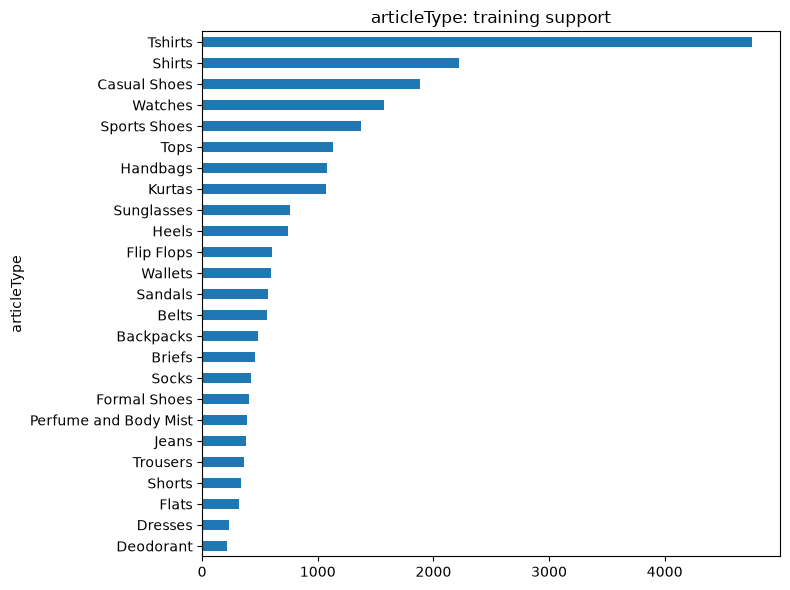

In [3]:
train_rows = metadata_by_target['articleType'].loc[metadata_by_target['articleType']['split'].eq('train')]
counts = train_rows['articleType'].value_counts()
counts.head(25).sort_values().plot.barh(figsize=(8, 6), title=f"{'articleType'}: training support")
plt.tight_layout()
plt.show()


### 4.2. Training, Validation & Test Partitions

Reuse the frozen product-group split. Within validation, use separate groups for selection, temperature fitting and policy checking. Do not use the internal test to select candidates.


In [4]:
def validation_views(frame):
    selection_ids, rest_ids = next(GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED)
                                   .split(frame, groups=frame.group_key))
    selection, rest = frame.iloc[selection_ids], frame.iloc[rest_ids]
    cal_ids, policy_ids = next(GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED + 1)
                              .split(rest, groups=rest.group_key))
    return selection, rest.iloc[cal_ids], rest.iloc[policy_ids]


In [5]:
frames, labels_by_target = ({}, {})
selection, calibration, policy = validation_views(metadata_by_target['articleType'].loc[metadata_by_target['articleType']['split'].eq('validation')])
frames['articleType'] = dict(train=metadata_by_target['articleType'].loc[metadata_by_target['articleType']['split'].eq('train')], selection=selection, calibration=calibration, policy=policy)
groups = [set(frame.group_key) for frame in frames['articleType'].values()]
assert all((a.isdisjoint(b) for i, a in enumerate(groups) for b in groups[i + 1:]))
labels_by_target['articleType'] = sorted(frames['articleType']['train']['articleType'].unique())
display(pd.Series({name: len(frame) for name, frame in frames['articleType'].items()}, name='articleType'))


train          27051
selection       2900
calibration     1378
policy          1564
Name: articleType, dtype: int64

### 4.3. Image Preprocessing

Resize RGB to 96 x 128 pixels (width x height), then normalize using training-only channel statistics. The batch class stores decoded uint8 images and converts one batch at a time to float32. Horizontal flips are applied inside each model only during training.


In [6]:
class CachedBatches(keras.utils.PyDataset):
    """Decode RGB once to uint8 RAM, then normalize each NHWC batch."""
    def __init__(self, frame, target, labels, normalisation, training=False, batch_size=64):
        super().__init__(workers=0, max_queue_size=2)
        self.dataset = frame
        self.training, self.batch_size = training, batch_size
        def read(path):
            with Image.open(path) as image:
                return np.asarray(image.convert("RGB").resize(IMAGE_SIZE, Image.Resampling.BILINEAR)).copy()
        with ThreadPoolExecutor(max_workers=4) as pool:
            self.images = np.stack(list(pool.map(read, frame.image_path)))
        self.targets = np.asarray([labels.index(label) for label in frame[target]], dtype=np.int32)
        self.mean = np.asarray(normalisation["mean"], dtype=np.float32)
        self.std = np.asarray(normalisation["std"], dtype=np.float32)
        self.reset()

    def reset(self):
        self.rng = np.random.default_rng(SEED)
        self.indices = np.arange(len(self.dataset))
        if self.training:
            self.rng.shuffle(self.indices)

    def __len__(self):
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size

    def __getitem__(self, index):
        ids = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        images = self.images[ids].astype(np.float32) / 255.0
        return (images - self.mean) / self.std, self.targets[ids]

    def on_epoch_end(self):
        if self.training:
            self.rng.shuffle(self.indices)


### 4.4. Feature Batches & Label Encoding

Map sorted label names to integer indices, preserving the same order for every model. Construct shuffled training batches and fixed-order selection batches.


In [7]:
normalisation = json.loads(NORMALISATION_PATH.read_text())
loaders = {}
labels = labels_by_target['articleType']
loaders['articleType'] = {name: CachedBatches(frames['articleType'][name], 'articleType', labels, normalisation, training=name == 'train', batch_size=BATCH_SIZE) for name in ['train', 'selection']}


## 5. Model Development & Evaluation

This section develops three neural-network families trained from scratch on the supplied fashion images. Moving from flattened pixels to deeper dense layers and then spatial convolutions lets us examine how architecture affects performance under the same evaluation protocol.

**Models included:**

- **5.1. Shallow MLP (Baseline):** Establishes the performance of one hidden layer on flattened RGB input.
- **5.2. Deeper MLP:** Tests whether additional dense layers improve the learned representation and generalization.
- **5.3. Convolutional Neural Network (CNN):** Learns spatial features and compares the declared convolutional configurations and learning-rate schedules.

Each model subsection shows its architecture, compilation, and training code. All candidates use the same image size, normalization, batch size, training/selection groups, Adam optimizer, and maximum epoch budget. Training-only horizontal flips and dropout provide regularization. Early stopping restores the epoch with the highest selection macro-F1; scheduled CNNs additionally reduce the learning rate when that metric stalls.

The following subsections compare the restored models, plot learning curves, and evaluate the selected model. Model selection prioritizes **validation macro-F1**, then accuracy, then parameter count. Calibration and review thresholds use separate validation groups. The internal test is evaluated after selection and must not be used to choose an architecture.


### Evaluation Metric: Macro-F1

Accumulate the full-epoch confusion matrix and average F1 over classes with positive ground-truth support. This metric selects the restored epoch and winning model. It does not average per-batch F1 scores.

The displayed per-class classification report also includes every output label for coverage auditing. Its standard `macro avg` row therefore includes zero-support output labels and can differ from the supported-class macro-F1 used for selection. Read the explicitly reported selection metric for model ranking, and inspect support before making claims about all classes. Selection support is 97/124 article types, 4/4 seasons, 5/5 gender categories and 8/9 occasion labels for this frozen run.


In [8]:
@keras.utils.register_keras_serializable(package="Fashion")
class SupportedMacroF1(keras.metrics.Metric):
    """Macro-F1 over classes present in the full epoch's ground truth."""
    def __init__(self, num_classes, name="macro_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.matrix = self.add_weight(name="matrix", shape=(num_classes, num_classes), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        truth = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        predictions = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        weights = None if sample_weight is None else tf.cast(tf.reshape(sample_weight, [-1]), self.dtype)
        self.matrix.assign_add(tf.math.confusion_matrix(truth, predictions, self.num_classes,
                                                        weights=weights, dtype=self.dtype))

    def result(self):
        support = tf.reduce_sum(self.matrix, axis=1)
        predicted = tf.reduce_sum(self.matrix, axis=0)
        f1 = tf.math.divide_no_nan(2 * tf.linalg.diag_part(self.matrix), support + predicted)
        mask = tf.cast(support > 0, self.dtype)
        return tf.math.divide_no_nan(tf.reduce_sum(f1 * mask), tf.reduce_sum(mask))

    def reset_state(self):
        self.matrix.assign(tf.zeros_like(self.matrix))

    def get_config(self):
        return {**super().get_config(), "num_classes": self.num_classes}


### Saved-Model Metadata

An identity layer stores label order, preprocessing and confidence policy inside each exported Keras model.


In [9]:
@keras.utils.register_keras_serializable(package="Fashion")
class ModelMetadata(keras.layers.Layer):
    """Store label order, preprocessing and calibration inside the .keras file."""
    def __init__(self, metadata=None, **kwargs):
        super().__init__(**kwargs)
        self.metadata = dict(metadata or {})

    def call(self, inputs):
        return inputs

    def get_config(self):
        return {**super().get_config(), "metadata": dict(self.metadata)}


### Export Every Experimental Candidate

Save restored weights immediately after each fit so a later interruption does not discard completed candidates. Exports contain inference weights without optimizer storage; resuming training requires rerunning that candidate.


In [10]:
def export_candidate(target, method):
    """Save every restored candidate immediately, without optimizer slots."""
    model = models[target][method]
    metadata = dict(
        target=target, labels=labels_by_target[target], model_type=method,
        temperature=1.0, mean=normalisation['mean'], std=normalisation['std'],
        image_size=list(IMAGE_SIZE), experiment_scope='filter_comparison',
        calibration_status='uncalibrated_candidate', seed=SEED,
    )
    exported = keras.models.clone_model(model)
    exported.set_weights(model.get_weights())
    exported.get_layer('metadata').metadata = metadata
    path = OUTPUT / f'{stem_for(target)}_{method}.keras'
    exported.save(path)
    history = histories[target][method]
    history.to_csv(RESULTS / f'{stem_for(target)}_{method}_history.csv', index=False)
    configuration = dict(
        target=target, method=method, model_file=path.name,
        model_sha256=hashlib.sha256(path.read_bytes()).hexdigest(),
        architecture=json.loads(exported.to_json()),
        optimizer=keras.optimizers.serialize(model.optimizer),
        seed=SEED, batch_size=BATCH_SIZE, epochs_run=len(history),
        best_epoch=int(history['val_macro_f1'].to_numpy().argmax()) + 1,
        tensorflow_version=tf.__version__, keras_version=keras.__version__,
        candidate_calibrated=False,
    )
    (RESULTS / f'{stem_for(target)}_{method}_configuration.json').write_text(
        json.dumps(configuration, indent=2, default=lambda value: value.item()) + '\n')
    print('Saved candidate:', path, flush=True)


In [11]:
models = {'articleType': {}}
histories = {'articleType': {}}


### 5.1. Shallow MLP (Baseline)


The shallow MLP is the baseline for this experiment. It learns combinations of flattened pixel values through one hidden layer but has no convolutional mechanism for local spatial patterns. Its measured performance provides the reference for the deeper models.


#### 5.1.1. Model Architecture

Flatten the image and use one 256-unit hidden layer as the baseline. ReLU provides nonlinearity; dropout reduces reliance on individual activations. The output is logits, with one value per class.


In [12]:
keras.utils.set_random_seed(SEED)
layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
for width in [256]:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['articleType'])), ModelMetadata(name='metadata')])
models['articleType']['shallow_mlp'] = keras.Sequential(layers, name='shallow_mlp')
models['articleType']['shallow_mlp'].summary()


I0000 00:00:1789117997.436578  266842 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "shallow_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 124)            │        31,868 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 124)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,469,308 (36.12 MB)

 Trainable params: 9,469,308 (36.12 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.1.2. Compile the Model

Adam starts at 0.001. Sparse cross-entropy accepts integer labels and logits; accuracy and macro-F1 are recorded for both training and selection data.


In [13]:
model = models['articleType']['shallow_mlp']
model.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['articleType']))])


#### 5.1.3. Train the Model

Stop after seven epochs without improved selection macro-F1 and restore the best weights. Reset batch order so candidates start from the same seeded ordering. This cell trains from scratch when rerun.


In [14]:
loaders['articleType']['train'].reset()
callback = keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True)
fitted = models['articleType']['shallow_mlp'].fit(loaders['articleType']['train'], validation_data=loaders['articleType']['selection'], epochs=MAX_EPOCHS, callbacks=[callback], shuffle=False, verbose=2)
histories['articleType']['shallow_mlp'] = pd.DataFrame(fitted.history)
export_candidate('articleType', 'shallow_mlp')
display(histories['articleType']['shallow_mlp'].tail())


Epoch 1/30


423/423 - 12s - 28ms/step - accuracy: 0.4242 - loss: 3.3278 - macro_f1: 0.0861 - val_accuracy: 0.5421 - val_loss: 2.7433 - val_macro_f1: 0.1421


Epoch 2/30


423/423 - 11s - 25ms/step - accuracy: 0.5100 - loss: 2.4309 - macro_f1: 0.1219 - val_accuracy: 0.5603 - val_loss: 2.0352 - val_macro_f1: 0.1560


Epoch 3/30


...

423/423 - 11s - 27ms/step - accuracy: 0.6351 - loss: 1.4516 - macro_f1: 0.2347 - val_accuracy: 0.6362 - val_loss: 5.5146 - val_macro_f1: 0.2314


Epoch 30/30


423/423 - 11s - 27ms/step - accuracy: 0.6215 - loss: 1.7554 - macro_f1: 0.2270 - val_accuracy: 0.6383 - val_loss: 5.8084 - val_macro_f1: 0.2324


Saved candidate: /mnt/d/khoile/programs/fashion-intelligence-classification/models-test/article_type_shallow_mlp.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
25,0.628369,1.422579,0.242340,0.661724,4.390100,0.262202
26,0.628332,1.576056,0.233096,0.671724,2.982040,0.280479
27,0.624117,2.006891,0.219700,0.657586,4.223036,0.266122
28,0.635097,1.451572,0.234706,0.636207,5.514629,0.231386
29,0.621530,1.755447,0.227021,0.638276,5.808415,0.232390


#### 5.1.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.


articleType shallow_mlp


selection_accuracy    0.671724
selection_macro_f1    0.280479
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,0.909091,0.833333,0.869565,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.833333,0.740741,0.784314,54.000000
Bangle,0.000000,0.000000,0.000000,13.000000
Basketballs,0.000000,0.000000,0.000000,3.000000
...,...,...,...,...
Water Bottle,0.000000,0.000000,0.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.671724,0.671724,0.671724,0.671724
macro avg,0.236340,0.222199,0.219407,2900.000000


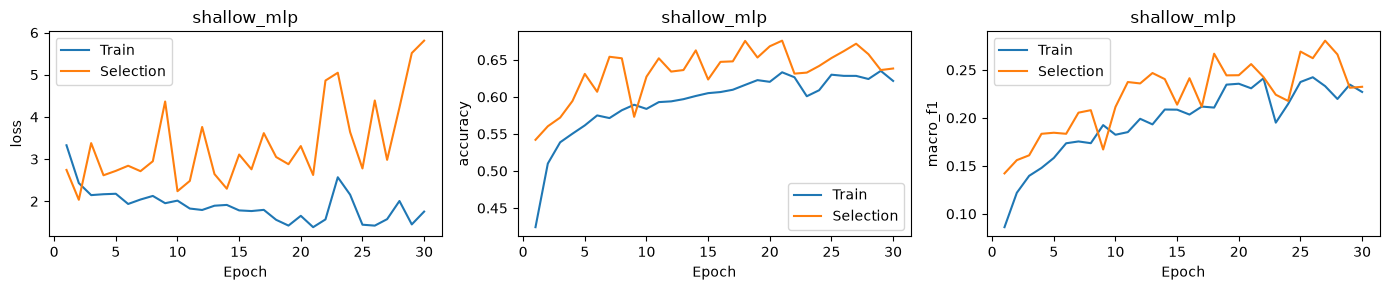

In [15]:
loader = loaders['articleType']['selection']
for method in ['shallow_mlp']:
    model = models['articleType'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('articleType', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['articleType'])), target_names=labels_by_target['articleType'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_selection_per_class.csv")
    history = histories['articleType'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('articleType')}_{method}_learning_curves.png", dpi=160)
    plt.show()


#### 5.1.5. Evaluation Analysis

Results pending this experimental run. Interpret the generated selection tables and per-class reports after execution; no production scores are claimed as experimental results.


### 5.2. Deeper MLP


The deeper MLP processes the same flattened RGB input through three hidden layers. ReLU activations allow successive nonlinear transformations, while dropout reduces reliance on individual activations. Compare its validation metrics and learning-curve gap with the shallow baseline before concluding that depth is useful.


#### 5.2.1. Model Architecture

Flatten the image and use three hidden layers to test whether additional nonlinear transformations improve generalization. ReLU provides nonlinearity; dropout reduces reliance on individual activations. The output is logits, with one value per class.


In [16]:
keras.utils.set_random_seed(SEED)
layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
for width in [256, 128, 64]:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['articleType'])), ModelMetadata(name='metadata')])
models['articleType']['deeper_mlp'] = keras.Sequential(layers, name='deeper_mlp')
models['articleType']['deeper_mlp'].summary()


Model: "deeper_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 124)            │         8,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 124)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,486,652 (36.19 MB)

 Trainable params: 9,486,652 (36.19 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2.2. Compile the Model

Adam starts at 0.001. Sparse cross-entropy accepts integer labels and logits; accuracy and macro-F1 are recorded for both training and selection data.


In [17]:
model = models['articleType']['deeper_mlp']
model.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['articleType']))])


#### 5.2.3. Train the Model

Stop after seven epochs without improved selection macro-F1 and restore the best weights. Reset batch order so candidates start from the same seeded ordering. This cell trains from scratch when rerun.


In [18]:
loaders['articleType']['train'].reset()
callback = keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True)
fitted = models['articleType']['deeper_mlp'].fit(loaders['articleType']['train'], validation_data=loaders['articleType']['selection'], epochs=MAX_EPOCHS, callbacks=[callback], shuffle=False, verbose=2)
histories['articleType']['deeper_mlp'] = pd.DataFrame(fitted.history)
export_candidate('articleType', 'deeper_mlp')
display(histories['articleType']['deeper_mlp'].tail())


Epoch 1/30


423/423 - 13s - 30ms/step - accuracy: 0.3546 - loss: 2.8472 - macro_f1: 0.0622 - val_accuracy: 0.5210 - val_loss: 1.7409 - val_macro_f1: 0.1246


Epoch 2/30


423/423 - 12s - 28ms/step - accuracy: 0.4991 - loss: 1.8696 - macro_f1: 0.1041 - val_accuracy: 0.5800 - val_loss: 1.5099 - val_macro_f1: 0.1566


Epoch 3/30


...

423/423 - 11s - 27ms/step - accuracy: 0.6655 - loss: 1.1485 - macro_f1: 0.2086 - val_accuracy: 0.6741 - val_loss: 1.1005 - val_macro_f1: 0.2664


Epoch 23/30


423/423 - 11s - 26ms/step - accuracy: 0.6719 - loss: 1.1051 - macro_f1: 0.2174 - val_accuracy: 0.6810 - val_loss: 1.1005 - val_macro_f1: 0.2565


Saved candidate: /mnt/d/khoile/programs/fashion-intelligence-classification/models-test/article_type_deeper_mlp.keras


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
18,0.662822,1.155732,0.203221,0.690345,1.078258,0.264425
19,0.666112,1.134315,0.210075,0.680690,1.110584,0.272139
20,0.664929,1.142532,0.211707,0.697931,1.081789,0.266125
21,0.665521,1.148533,0.208609,0.674138,1.100471,0.266353
22,0.671879,1.105124,0.217446,0.681035,1.100453,0.256522


#### 5.2.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.


articleType deeper_mlp


selection_accuracy    0.701379
selection_macro_f1    0.285285
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,0.833333,0.909091,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.803571,0.833333,0.818182,54.000000
Bangle,1.000000,0.153846,0.266667,13.000000
Basketballs,0.000000,0.000000,0.000000,3.000000
...,...,...,...,...
Water Bottle,0.000000,0.000000,0.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.701379,0.701379,0.701379,0.701379
macro avg,0.248449,0.240459,0.223166,2900.000000


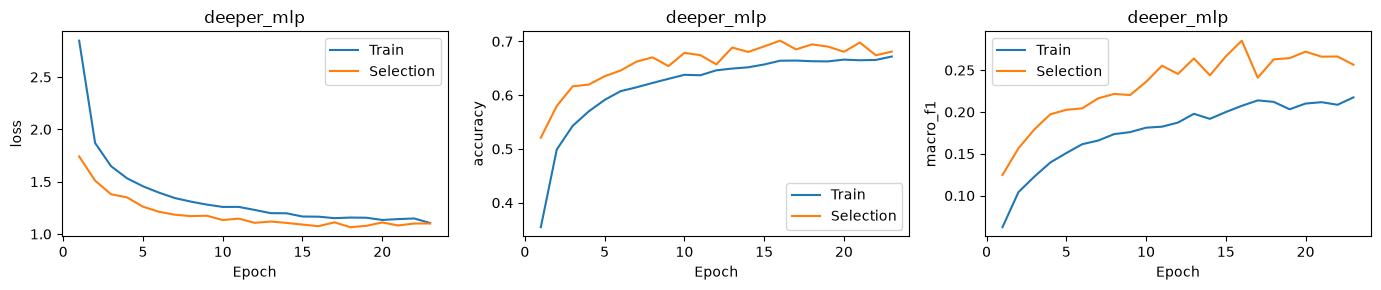

In [19]:
loader = loaders['articleType']['selection']
for method in ['deeper_mlp']:
    model = models['articleType'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('articleType', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['articleType'])), target_names=labels_by_target['articleType'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_selection_per_class.csv")
    history = histories['articleType'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('articleType')}_{method}_learning_curves.png", dpi=160)
    plt.show()


#### 5.2.5. Evaluation Analysis

Results pending this experimental run. Interpret the generated selection tables and per-class reports after execution; no production scores are claimed as experimental results.


### 5.3. Convolutional Neural Network (CNN)

Six initial CNN configurations compare depth, scheduling and filter width. All remain members of the CNN family. The filter-only comparison uses the four scheduled four-block architectures.


#### 5.3.1. Model Architecture

Retain the two three-block controls and compare the four-block reference with narrow, capped-final-block and wider-final-block variants. All four-block candidates keep the same Dense(256) head and training recipe.


In [20]:
CNN_CONFIGS = {'cnn_ordinary': ((32, 64, 128), 128, False), 'cnn_scheduled': ((32, 64, 128), 128, True), 'cnn_four_blocks_scheduled': ((32, 64, 128, 256), 256, True), 'cnn_narrow_scheduled': ((16, 32, 64, 128), 256, True), 'cnn_capped_scheduled': ((32, 64, 128, 128), 256, True), 'cnn_wide_scheduled': ((32, 64, 128, 384), 256, True)}
for method, (channels, hidden, scheduled) in CNN_CONFIGS.items():
    keras.utils.set_random_seed(SEED)
    layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal')]
    for width in channels:
        layers.extend([keras.layers.Conv2D(width, 3, padding='same'), keras.layers.BatchNormalization(), keras.layers.Activation('relu'), keras.layers.MaxPooling2D(2)])
    h, w = (IMAGE_SIZE[1] // 2 ** len(channels), IMAGE_SIZE[0] // 2 ** len(channels))
    layers.extend([keras.layers.AveragePooling2D((h // 2, w // 2)), keras.layers.Flatten(), keras.layers.Dense(hidden, activation='relu'), keras.layers.Dropout(0.2), keras.layers.Dense(len(labels_by_target['articleType'])), ModelMetadata(name='metadata')])
    models['articleType'][method] = keras.Sequential(layers, name=method)
    models['articleType'][method].summary()


Model: "cnn_ordinary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 2, 2, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 124)            │        15,996 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 124)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,804 (686.73 KB)

 Trainable params: 175,356 (684.98 KB)

 Non-trainable params: 448 (1.75 KB)

...

Model: "cnn_wide_scheduled"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_7 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 128, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 128, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 64, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 64, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 32, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 32, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 12, 384)    │       442,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 16, 12, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 8, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 2, 2, 384)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 124)            │        31,868 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 963,772 (3.68 MB)

 Trainable params: 962,556 (3.67 MB)

 Non-trainable params: 1,216 (4.75 KB)

#### 5.3.2. Compile the CNN Models

Keep optimizer, loss and metrics the same as the MLPs so the comparison tests architecture and the declared schedule.


In [21]:
for method in CNN_CONFIGS:
    models['articleType'][method].compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['articleType']))])


#### 5.3.3. Train and Tune the CNN Models

Scheduled variants halve the learning rate after two epochs without improvement. All variants stop after seven stale epochs. Selection data controls these decisions; test data is not read here.


In [ ]:
for method, (_, _, scheduled) in CNN_CONFIGS.items():
    loaders['articleType']['train'].reset()
    callbacks = []
    if scheduled:
        callbacks.append(keras.callbacks.ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=2))
    callbacks.append(keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True))
    fitted = models['articleType'][method].fit(loaders['articleType']['train'], validation_data=loaders['articleType']['selection'], epochs=MAX_EPOCHS, callbacks=callbacks, shuffle=False, verbose=2)
    histories['articleType'][method] = pd.DataFrame(fitted.history)
    export_candidate('articleType', method)
    display(histories['articleType'][method].tail())


#### 5.3.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.


In [ ]:
loader = loaders['articleType']['selection']
for method in list(CNN_CONFIGS):
    model = models['articleType'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('articleType', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['articleType'])), target_names=labels_by_target['articleType'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_selection_per_class.csv")
    history = histories['articleType'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('articleType')}_{method}_learning_curves.png", dpi=160)
    plt.show()


#### 5.3.5. Evaluation Analysis

Results pending this experimental run. Interpret the generated selection tables and per-class reports after execution; no production scores are claimed as experimental results.


#### 5.3.6. Target-specific parameter tuning

The completed first run motivates lower learning rates for the unstable MLPs and a short CNN continuation with and without class weighting. These are additional candidates, not assumed improvements. Only training counts determine weights; selection macro-F1 chooses the winner. Calibration, policy and internal-test images are excluded from fitting.

Both CNN candidates start from identical selected CNN weights. Their shared learning rate, dropout, seed and epoch budget isolate the effect of class weights. Each MLP keeps its original architecture and uses a lower learning rate for up to 20 epochs. CNN continuation uses up to 8 additional epochs; its history records additional epochs only.

This experimental Run All trains all candidates afresh. RESUME_SAVED_RESULTS remains False to prevent mixing earlier results with this run. Both continuation candidates use the fresh four-block reference, regardless of which filter alternative wins.


**articleType: configure candidates and training-only weights.** Normalize square-root inverse-frequency weights to mean one over training examples, then cap them at 4 to limit the influence of extremely rare labels. Validation metrics remain unweighted.


In [ ]:
PARAMETER_CONFIGS_articleType = {
    'shallow_mlp_lower_lr': dict(family='shallow_mlp', learning_rate=1e-4, epochs=20, weighted=False),
    'deeper_mlp_lower_lr': dict(family='deeper_mlp', learning_rate=3e-4, epochs=20, weighted=False),
    'cnn_continue': dict(family='cnn', learning_rate=3e-05, epochs=8, weighted=False),
    'cnn_continue_weighted': dict(family='cnn', learning_rate=3e-05, epochs=8, weighted=True),
}
counts = np.bincount(loaders['articleType']['train'].targets, minlength=len(labels_by_target['articleType']))
assert (counts > 0).all()
weights = np.sqrt(counts.sum() / (len(counts) * counts))
weights = np.clip(weights / np.average(weights, weights=counts), 0.25, 4)
class_weights_articleType = {i: float(value) for i, value in enumerate(weights)}
if 'cnn_four_blocks_scheduled' in models['articleType']:
    tuning_source_articleType = models['articleType']['cnn_four_blocks_scheduled']
else:
    tuning_source_articleType = keras.models.load_model(OUTPUT / f"{stem_for('articleType')}_model.keras", compile=False)
    saved_metadata = tuning_source_articleType.get_layer('metadata').metadata
    assert saved_metadata['target'] == 'articleType' and saved_metadata['labels'] == labels_by_target['articleType']
    assert saved_metadata['model_type'].startswith('cnn')
    assert saved_metadata['image_size'] == list(IMAGE_SIZE)
    np.testing.assert_allclose(saved_metadata['mean'], normalisation['mean'])
    np.testing.assert_allclose(saved_metadata['std'], normalisation['std'])
    models['articleType'][saved_metadata['model_type']] = tuning_source_articleType
for method, config in PARAMETER_CONFIGS_articleType.items():
    keras.utils.set_random_seed(SEED)
    if config['family'] == 'cnn':
        candidate = keras.models.clone_model(tuning_source_articleType)
        candidate.set_weights(tuning_source_articleType.get_weights())
        candidate.get_layer('metadata').metadata = {}
    else:
        widths = [256] if config['family'] == 'shallow_mlp' else [256, 128, 64]
        layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
        for width in widths:
            layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
        layers.extend([keras.layers.Dense(len(labels_by_target['articleType'])), ModelMetadata(name='metadata')])
        candidate = keras.Sequential(layers, name=method)
    candidate.compile(optimizer=keras.optimizers.Adam(config['learning_rate']), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['articleType']))])
    models['articleType'][method] = candidate
pd.DataFrame(PARAMETER_CONFIGS_articleType).T.to_csv(RESULTS / f"{stem_for('articleType')}_parameter_configs.csv")
display(pd.DataFrame(PARAMETER_CONFIGS_articleType).T)


**articleType: fit the additional candidates.** Early stopping restores the best selection macro-F1. Paired CNN runs reset random state and batch ordering. Class weights affect training loss only ([Keras training API](https://keras.io/api/models-test/model_training_apis/)).


In [ ]:
for method, config in PARAMETER_CONFIGS_articleType.items():
    keras.utils.set_random_seed(SEED)
    loaders['articleType']['train'].reset()
    callbacks = [keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True)]
    print('articleType', method, flush=True)
    fitted = models['articleType'][method].fit(loaders['articleType']['train'], validation_data=loaders['articleType']['selection'], epochs=config['epochs'], callbacks=callbacks, class_weight=class_weights_articleType if config['weighted'] else None, shuffle=False, verbose=2)
    histories['articleType'][method] = pd.DataFrame(fitted.history)
    export_candidate('articleType', method)
    histories['articleType'][method].to_csv(RESULTS / f"{stem_for('articleType')}_{method}_history.csv", index=False)
    display(histories['articleType'][method].tail())


**articleType: evaluate on selection images.** The final comparison keeps the best candidate within each family. Rare-class recall accompanies overall scores; continuation is retained only if it wins the declared ranking.


In [ ]:
loader = loaders['articleType']['selection']
for method in PARAMETER_CONFIGS_articleType:
    probabilities = np.vstack([tf.nn.softmax(models['articleType'][method](loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(1)
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['articleType'])), target_names=labels_by_target['articleType'], output_dict=True, zero_division=0)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_selection_per_class.csv")
    display(pd.Series(dict(method=method, accuracy=accuracy_score(loader.targets, predictions), macro_f1=f1_score(loader.targets, predictions, labels=np.unique(loader.targets), average='macro', zero_division=0))))


### 5.4. Model Comparison

Choose the best configuration within each of the three families using selection macro-F1, then accuracy, then fewer parameters. Original runs and the additional parameter experiments are compared on the same selection partition. The three-row table reports family winners; the experiments CSV retains candidate-level evidence.


In [ ]:
def supported_macro_f1(truth, predictions) -> float:
    """Macro-average over labels present in the ground-truth partition."""
    return float(f1_score(
        truth, predictions, labels=np.unique(truth), average="macro", zero_division=0
    ))

def expected_calibration_error(
    truth: np.ndarray,
    probabilities: np.ndarray,
    bins: int = 10,
) -> float:
    """Compute top-label expected calibration error."""
    truth = np.asarray(truth)
    probabilities = np.asarray(probabilities)
    confidence = probabilities.max(axis=1)
    correct = probabilities.argmax(axis=1) == truth
    edges = np.linspace(0.0, 1.0, bins + 1)
    total = len(truth)
    error = 0.0
    for lower, upper in zip(edges[:-1], edges[1:], strict=True):
        selected = (confidence > lower) & (confidence <= upper)
        if selected.any():
            error += selected.sum() / total * abs(
                float(correct[selected].mean()) - float(confidence[selected].mean())
            )
    return float(error)

def ranked(table):
    """Predeclared: macro F1, then accuracy, then fewer parameters."""
    return table.sort_values(['validation_macro_f1', 'validation_accuracy', 'complexity_parameters'],
                             ascending=[False, False, True], kind='stable')


In [ ]:
comparisons, tuning, winners, checkpoints = ({}, {}, {}, {})
rows = []
loader = loaders['articleType']['selection']
for method, model in models['articleType'].items():
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    rows.append(dict(method=method, validation_accuracy=accuracy_score(loader.targets, probabilities.argmax(1)), validation_macro_f1=supported_macro_f1(loader.targets, probabilities.argmax(1)), validation_ece=expected_calibration_error(loader.targets, probabilities), complexity_parameters=model.count_params(), epochs_run=len(histories['articleType'][method])))
experiments = pd.DataFrame(rows).set_index('method')
# Resume measured candidates whose weights were not exported after kernel shutdown.
previous_path = RESULTS / f"{stem_for('articleType')}_experiments.csv"
if RESUME_SAVED_RESULTS and previous_path.exists():
    previous = pd.read_csv(previous_path, index_col='method')
    experiments = pd.concat([previous.loc[~previous.index.isin(experiments.index)], experiments])
experiments.to_csv(RESULTS / f"{stem_for('articleType')}_experiments.csv")
tuning['articleType'] = experiments.loc[experiments.index.str.startswith('cnn')].copy()
for metric in ['accuracy', 'macro_f1']:
    tuning['articleType'][f'{metric}_change_vs_ordinary'] = tuning['articleType'][f'validation_{metric}'] - tuning['articleType'].loc['cnn_ordinary', f'validation_{metric}']
best_cnn = ranked(tuning['articleType']).index[0]
best_shallow = ranked(experiments.loc[experiments.index.str.startswith('shallow_mlp')]).index[0]
best_deeper = ranked(experiments.loc[experiments.index.str.startswith('deeper_mlp')]).index[0]
table = experiments.loc[[best_shallow, best_deeper, best_cnn]].copy()
table['family'] = ['shallow_mlp', 'deeper_mlp', 'cnn']
winners['articleType'] = ranked(table).index[0]
table['selected'] = table.index == winners['articleType']
comparisons['articleType'] = table
table.to_csv(RESULTS / f"{stem_for('articleType')}_comparison.csv")
tuning['articleType'].to_csv(RESULTS / f"{stem_for('articleType')}_cnn_tuning.csv")
display(table)
display(tuning['articleType'])
assert winners['articleType'] in models['articleType'], 'Winning weights are missing; retrain that candidate before export.'


#### Filter-only comparison

Compare only equally trained four-block CNNs here. Gains are relative to the fresh reference run, not the separately continued production winner.


In [ ]:
filter_methods = ['cnn_four_blocks_scheduled', 'cnn_narrow_scheduled', 'cnn_capped_scheduled', 'cnn_wide_scheduled']
filter_table = tuning['articleType'].loc[filter_methods].copy()
reference = filter_table.loc['cnn_four_blocks_scheduled']
filter_table['macro_f1_change_vs_reference'] = filter_table.validation_macro_f1 - reference.validation_macro_f1
filter_table['accuracy_change_vs_reference'] = filter_table.validation_accuracy - reference.validation_accuracy
filter_table = ranked(filter_table)
filter_table.to_csv(RESULTS / f"{stem_for('articleType')}_filter_comparison.csv")
display(filter_table)


### 5.5. Learning Curves

Inspect the restored best epoch and later trajectory rather than the final epoch alone. Training enables augmentation and dropout; selection uses inference mode, so a negative training-minus-selection accuracy gap is possible.

The class-weighted CNN uses weighted training loss but unweighted validation loss. Their raw loss gap does not directly measure overfitting. Accuracy and supported-class macro-F1 remain unweighted and are comparable across candidates, subject to the training/inference-mode difference. CNN continuation plots count additional epochs from the shared starting checkpoint.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for method, history in histories['articleType'].items():
    history = history.copy()
    history.insert(0, 'epoch', np.arange(1, len(history) + 1))
    history.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_history.csv", index=False)
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(history.epoch, history[metric], linestyle='--', alpha=0.6, label=f'{method}: train')
        ax.plot(history.epoch, history[f'val_{metric}'], label=f'{method}: selection')
        ax.set(xlabel='Epoch', ylabel=metric, title='articleType')
axes[-1].legend(fontsize=6)
fig.tight_layout()
fig.savefig(FIGURES / f"{stem_for('articleType')}_learning_curves.png", dpi=160)
plt.show()


### 5.6. Model Evaluation & Error Analysis

The following small inference helpers reproduce application preprocessing. Temperature scaling changes confidence, not the predicted class. Calibration is fitted on separate groups, then accepted only if policy-group NLL improves without worsening ECE.


#### 5.6.1. Prepare one inference image

Use the same RGB resizing and training-only normalization as the training batches.


In [ ]:
def image_batch(image, image_size, mean, std):
    resized = image.convert("RGB").resize(tuple(image_size), Image.Resampling.BILINEAR)
    array = np.asarray(resized, dtype=np.float32) / 255.0
    array = (array - np.asarray(mean, dtype=np.float32)) / np.asarray(std, dtype=np.float32)
    return array[None, ...]


#### 5.6.2. Rescale confidence

Divide log probabilities by a positive temperature and renormalize.


In [ ]:
def temperature_scale(probabilities, temperature=1.0):
    """Rescale confidence without changing the highest-probability class."""
    if not np.isfinite(temperature) or temperature <= 0:
        raise ValueError('Temperature must be finite and positive')
    values = np.asarray(probabilities, dtype=np.float64)
    if values.ndim < 1 or values.shape[-1] == 0 or (not np.isfinite(values).all()) or (values < 0).any():
        raise ValueError('Probabilities must be finite, nonnegative vectors')
    mass = values.sum(axis=-1, keepdims=True)
    if (mass <= 0).any():
        raise ValueError('Probability vectors must have positive mass')
    values = values / mass
    if temperature == 1.0:
        return values
    logits = np.log(np.clip(values, np.finfo(np.float64).tiny, 1.0)) / temperature
    logits -= logits.max(axis=-1, keepdims=True)
    scaled = np.exp(logits)
    return scaled / scaled.sum(axis=-1, keepdims=True)


#### 5.6.3. Notebook prediction interface

Use the same logits, labels and review-policy semantics as the web application. This class performs inference only.


In [ ]:
class FashionClassifier:
    def __init__(self, checkpoint_path, device=None):
        checkpoint = checkpoint_path if isinstance(checkpoint_path, dict) else load_checkpoint(checkpoint_path)
        self.device = "/CPU:0" if device == "cpu" else (device if device and str(device).startswith("/") else None)
        self.target, self.labels = checkpoint["target"], list(checkpoint["labels"])
        self.temperature = float(checkpoint.get("temperature", 1.0))
        self.review_policy = checkpoint.get("review_policy")
        self.model_type = checkpoint["model_type"]
        self.model = checkpoint.get("model")
        self.members = None
        if self.model is not None:
            self.mean, self.std = checkpoint["mean"], checkpoint["std"]
            self.image_size = checkpoint["image_size"]
            self.estimator = self.feature_config = None
        else:
            raise ValueError("Classifier has no trained Keras model")

    def predict_batch(self, inputs):
        with tf.device(self.device):
            probabilities = tf.nn.softmax(self.model(inputs, training=False), axis=-1).numpy()
        return temperature_scale(probabilities, self.temperature)

    def predict_probabilities(self, image):
        inputs = image_batch(image, self.image_size, self.mean, self.std)
        return self.predict_batch(inputs)[0]

    def predict(self, image: Image.Image, top_k: int = 3) -> dict:
        if top_k < 1:
            raise ValueError("top_k must be positive")
        probabilities = self.predict_probabilities(image)
        count = min(top_k, len(self.labels))
        indices = np.argsort(probabilities)[::-1][:count]
        ranked = [
            {"label": self.labels[int(index)], "confidence": float(probabilities[index])}
            for index in indices
        ]
        result = {
            "target": self.target,
            "label": ranked[0]["label"],
            "confidence": ranked[0]["confidence"],
            "top_k": ranked,
        }
        if self.review_policy is not None:
            threshold = self.review_policy['threshold']
            result['needs_review'] = threshold is None or ranked[0]['confidence'] < threshold
            result['review_threshold'] = threshold
            result['confidence_calibrated'] = self.temperature != 1.0
            if self.review_policy.get('brightness_stability') and not result['needs_review']:
                stable_label = int(indices[0])
                unstable = any(
                    int(self.predict_probabilities(ImageEnhance.Brightness(image.convert('RGB')).enhance(factor)).argmax()) != stable_label
                    for factor in (0.8, 1.2)
                )
                if unstable:
                    result['needs_review'] = True
                    result['review_reason'] = 'Prediction changes with lighting'
        return result


#### 5.6.4. Evaluate a partition

Compute accuracy, supported-class macro-F1, ECE, NLL and Brier score. Record sampled batch/single-image differences as a diagnostic; large differences or changed predictions warn, while invalid probabilities raise an error.


In [ ]:
def evaluate_saved_checkpoint(checkpoint_path, frame, device="cpu", batch_size=64):
    """Re-evaluate a frozen artifact with the application's exact preprocessing.

    This never fits a model or changes its checkpoint. Batching changes only
    execution and may slightly affect floating-point scores; label ordering
    and saved temperature match the web API.
    """
    from sklearn.metrics import log_loss

    if frame.empty:
        raise ValueError("Evaluation requires at least one image")
    predictor = FashionClassifier(checkpoint_path, device=device)
    labels = predictor.labels
    truth = np.asarray([labels.index(label) for label in frame[predictor.target]])
    batches = []
    for start in range(0, len(frame), batch_size):
        inputs = []
        for path in frame.image_path.iloc[start:start + batch_size]:
            with Image.open(path) as source:
                inputs.append(image_batch(source, predictor.image_size, predictor.mean, predictor.std))
        batches.append(predictor.predict_batch(np.concatenate(inputs)))
    probabilities = np.vstack(batches)
    if (probabilities.shape != (len(frame), len(labels))
            or not np.isfinite(probabilities).all()
            or (probabilities < 0).any()
            or not np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-5, rtol=1e-5)):
        raise ValueError("Batch inference returned invalid probabilities")
    predictions = probabilities.argmax(1)
    metrics = {
        "accuracy": float(accuracy_score(truth, predictions)),
        "macro_f1": supported_macro_f1(truth, predictions),
        "ece": expected_calibration_error(truth, probabilities),
        "nll": float(log_loss(truth, probabilities, labels=np.arange(len(labels)))),
        "brier": float(np.mean(np.sum((probabilities - np.eye(len(labels))[truth]) ** 2, axis=1))),
    }
    # Batch and single-image GPU kernels can produce slightly different scores.
    # Sample this difference as a diagnostic, not a requirement for calibration.
    # A 0.001 absolute difference means 0.1 percentage points of probability;
    # it is a warning threshold, not a guarantee of equivalent predictions.
    import warnings

    positions = sorted({0, len(frame) // 2, len(frame) - 1})
    max_absolute_difference = 0.0
    prediction_mismatches = []
    for position in positions:
        with Image.open(frame.image_path.iloc[position]) as source:
            single = np.asarray(predictor.predict_probabilities(source))
        if (single.shape != probabilities[position].shape
                or not np.isfinite(single).all()
                or (single < 0).any()
                or not np.isclose(single.sum(), 1.0, atol=1e-5, rtol=1e-5)):
            raise ValueError("Single-image inference returned invalid probabilities")
        difference = float(np.max(np.abs(probabilities[position] - single)))
        max_absolute_difference = max(max_absolute_difference, difference)
        if predictions[position] != single.argmax():
            prediction_mismatches.append(position)
    inference_consistency = {
        "sample_count": len(positions),
        "max_absolute_difference": max_absolute_difference,
        "prediction_mismatch_positions": prediction_mismatches,
    }
    if max_absolute_difference > 1e-3 or prediction_mismatches:
        warnings.warn(
            f"Batch/single-image inference diagnostic: {inference_consistency}. "
            "Evaluation and calibration use batched probabilities. Inspect these "
            "differences before interpreting single-image application results.",
            RuntimeWarning, stacklevel=2,
        )
    return {"labels": labels, "truth": truth, "predictions": predictions,
            "probabilities": probabilities, "metrics": metrics,
            "inference_consistency": inference_consistency}


#### 5.6.5. Fit temperature and the review threshold

Search temperature on calibration groups, then use policy groups to decide whether to keep it and when to request manual review.


In [ ]:
def calibrate(checkpoint, calibration, policy, device):
    checkpoint = dict(checkpoint)
    cal = evaluate_saved_checkpoint(checkpoint, calibration, device=str(device))
    raw = evaluate_saved_checkpoint(checkpoint, policy, device=str(device))
    fit = minimize_scalar(lambda log_t: log_loss(
        cal['truth'], temperature_scale(cal['probabilities'], np.exp(log_t)),
        labels=np.arange(len(checkpoint['labels']))),
        bounds=(np.log(0.25), np.log(10)), method='bounded')
    temperature = float(np.exp(fit.x))
    scaled = temperature_scale(raw['probabilities'], temperature)
    if (log_loss(raw['truth'], scaled, labels=np.arange(len(checkpoint['labels']))) < raw['metrics']['nll']
            and expected_calibration_error(raw['truth'], scaled) <= raw['metrics']['ece']):
        checkpoint['temperature'] = temperature
    else:
        scaled = raw['probabilities']
    threshold = None
    for value in np.round(np.arange(0.50, 1.00, 0.01), 2):
        accepted = scaled.max(1) >= value
        if accepted.sum() >= 100 and np.mean(scaled.argmax(1)[accepted] == raw['truth'][accepted]) >= 0.90:
            threshold = float(value)
            break
    checkpoint['review_policy'] = {'threshold': threshold, 'target_accuracy': 0.90,
                                   'minimum_policy_samples': 100,
                                   'brightness_stability': checkpoint['target'] == 'articleType'}
    return checkpoint


In [ ]:
method = winners['articleType']
checkpoints['articleType'] = dict(target='articleType', labels=labels_by_target['articleType'], model=models['articleType'][method], model_type=method, temperature=1.0, mean=normalisation['mean'], std=normalisation['std'], image_size=list(IMAGE_SIZE), comparison_row=comparisons['articleType'].loc[method].to_dict())
checkpoints['articleType'] = calibrate(checkpoints['articleType'], frames['articleType']['calibration'], frames['articleType']['policy'], DEVICE)


#### 5.6.6. Evaluate the selected model on the internal test

Do not revise the architecture based on this table. Report prior development exposure and inspect per-class support before interpreting overall accuracy.


In [ ]:
test_results = {}
result = evaluate_saved_checkpoint(checkpoints['articleType'], metadata_by_target['articleType'].loc[metadata_by_target['articleType']['split'].eq('test')], device=DEVICE)
test_results['articleType'] = result
checkpoints['articleType']['test_metrics'] = result['metrics']
display(pd.Series(result['metrics'], name='articleType'))
report = classification_report(result['truth'], result['predictions'], labels=np.arange(len(result['labels'])), target_names=result['labels'], output_dict=True, zero_division=0)
display(pd.DataFrame(report).T)
pd.DataFrame(report).T.to_csv(RESULTS / f"{stem_for('articleType')}_test_per_class.csv")
pd.Series(result['metrics']).to_csv(RESULTS / f"{stem_for('articleType')}_test_metrics.csv")


#### 5.6.7. Confidence bins

Compare average confidence with actual accuracy within each bin. Low-support bins are less reliable.


In [ ]:
def calibration_table(truth: np.ndarray, probabilities: np.ndarray) -> pd.DataFrame:
    """Return a ten-bin reliability table for notebook evidence."""
    confidence = probabilities.max(axis=1)
    correct = probabilities.argmax(axis=1) == np.asarray(truth)
    frame = pd.DataFrame({"confidence": confidence, "correct": correct})
    frame["bin"] = pd.cut(
        frame.confidence, bins=np.linspace(0, 1, 11), include_lowest=True
    )
    return frame.groupby("bin", observed=False).agg(
        mean_confidence=("confidence", "mean"),
        accuracy=("correct", "mean"),
        samples=("correct", "size"),
    )


In [ ]:
result = test_results['articleType']
display(calibration_table(result['truth'], result['probabilities']))


#### 5.6.8. Confusion matrices

Rows are true labels and columns are predicted labels. The article-type plot groups uncommon predicted classes into an Other column for readability.


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
directory = RESULTS
stem = stem_for('articleType')
result = test_results['articleType']
labels = result['labels']
shown = task_frame('articleType', 'train')['articleType'].value_counts().head(20).index.tolist()
indices = [labels.index(label) for label in shown]
others = [i for i in range(len(labels)) if i not in indices]
matrix = confusion_matrix(result['truth'], result['predictions'], labels=np.arange(len(labels)))
counts = np.column_stack([matrix[indices][:, indices], matrix[indices][:, others].sum(1)])
normalized = counts / np.maximum(counts.sum(1, keepdims=True), 1)
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(normalized, xticklabels=shown + ['Other predicted class'], yticklabels=shown, cmap='Blues', vmin=0, vmax=1, ax=ax)
ax.set(xlabel='Predicted label', ylabel='True label')
ax.set_title(f"{'articleType'}: selected checkpoint / internal test")
fig.tight_layout()
fig.savefig(FIGURES / f'{stem}_confusion.png', dpi=160, bbox_inches='tight')
plt.show()


## 6. Ultimate Judgement

Results pending this experimental run. Interpret the generated selection tables and per-class reports after execution; no production scores are claimed as experimental results.


In [ ]:
winner = comparisons['articleType'].loc[winners['articleType']]
baseline = comparisons['articleType'].loc[comparisons['articleType']['family'].eq('shallow_mlp')].iloc[0]
display(pd.Series({'selected_method': winners['articleType'], 'selection_macro_f1': winner.validation_macro_f1, 'selection_accuracy': winner.validation_accuracy, 'macro_f1_gain_over_baseline': winner.validation_macro_f1 - baseline.validation_macro_f1, 'internal_test_accuracy': test_results['articleType']['metrics']['accuracy'], 'internal_test_macro_f1': test_results['articleType']['metrics']['macro_f1']}, name='articleType'))


### 6.1. Decision Analysis

Results pending this experimental run. Interpret the generated selection tables and per-class reports after execution; no production scores are claimed as experimental results.


## 7. Final Prediction

Save the selected model, reload it, and predict a sample image. Exported metadata allows the standalone prediction scripts and web application to apply the same preprocessing and confidence policy.


In [ ]:
def save_checkpoint(checkpoint, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path = path.with_suffix(".keras")
    model = checkpoint["model"]
    metadata = {key: value for key, value in checkpoint.items() if key != "model"}
    metadata = json.loads(json.dumps(metadata, default=lambda value: value.item()))
    model.get_layer("metadata").metadata = metadata
    # Export architecture, learned weights and metadata without optimizer slots.
    inference_model = keras.models.clone_model(model)
    inference_model.set_weights(model.get_weights())
    inference_model.save(path)
    return path


In [ ]:
stem, method = (stem_for('articleType'), winners['articleType'])
path = save_checkpoint(checkpoints['articleType'], OUTPUT / f'{stem}_model.keras')
histories['articleType'][method].to_csv(RESULTS / f'{stem}_history.csv', index=False)
summary = dict(target='articleType', selected=method, cnn_selected=ranked(tuning['articleType']).index[0], framework='tensorflow_keras', model_file=path.name, test_metrics=test_results['articleType']['metrics'], split_sizes={name: len(frame) for name, frame in frames['articleType'].items()}, test_scope='internal_test_with_prior_development_exposure')
(RESULTS / f'{stem}_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Saved', path)


### 7.1. Load the Saved Model & Predict

A successful reload checks the saved architecture and metadata. This example is a functional check, not an independent quality estimate.


In [ ]:
def resolve_classifier_path(path):
    path = Path(path)
    if path.exists():
        return path
    raise FileNotFoundError(f"Missing trained classifier: {path}. Run the classification notebook first.")

def load_checkpoint(path):
    path = resolve_classifier_path(path)
    if path.suffix == ".keras":
        model = keras.models.load_model(path, compile=False)
        return {**dict(model.get_layer("metadata").metadata), "model": model}
    raise ValueError(f"Unsupported classifier format: {path.suffix}")


In [ ]:
predictor = FashionClassifier(OUTPUT / f"{stem_for('articleType')}_model.keras")
with Image.open(frames['articleType']['selection'].image_path.iloc[0]) as image:
    print(predictor.predict(image))


## 8. Conclusion

Results pending this experimental run. Interpret the generated selection tables and per-class reports after execution; no production scores are claimed as experimental results.


## 9. Verify All Experimental Exports

Verify each candidate file, its architecture metadata and its output against its in-memory model. The manifest lists every candidate and selected export for later review.


In [ ]:
export_manifest = []

for method, candidate in models['articleType'].items():
    path = OUTPUT / f"{stem_for('articleType')}_{method}.keras"
    restored = keras.models.load_model(path, compile=False)
    metadata = restored.get_layer('metadata').metadata
    assert metadata['target'] == 'articleType' and metadata['model_type'] == method
    assert metadata['labels'] == labels_by_target['articleType']
    probe = loaders['articleType']['selection'][0][0][:1]
    np.testing.assert_allclose(candidate(probe, training=False).numpy(), restored(probe, training=False).numpy(), atol=1e-5, rtol=1e-4)
    export_manifest.append(dict(target='articleType', method=method, file=path.name, selected=method == winners['articleType'], bytes=path.stat().st_size, sha256=hashlib.sha256(path.read_bytes()).hexdigest()))
    del restored
assert (OUTPUT / f"{stem_for('articleType')}_model.keras").is_file()
pd.DataFrame(export_manifest).to_csv(RESULTS / 'task1_article_type_classification_model_manifest.csv', index=False)
display(pd.DataFrame(export_manifest))
